# Análisis de Series Temporales
## Trabajo Final - Maestría en Ciencias de Datos
### Predicción de Cortes de Energía con Prophet

**Materia:** Análisis de Series de Tiempo  
**Alumnos:** Arenas - Banegas - Marín - Zamora

---

## Resumen Ejecutivo

Este trabajo presenta un análisis predictivo de **cortes de energía eléctrica** utilizando Prophet. El dataset incluye:

- **Cortes:** Cantidad semanal de cortes de luz
- **Temp:** Temperatura media semanal (°C) — variable exógena
- **Hum:** Humedad relativa media semanal (%) — variable exógena

Se analiza la relación entre temperatura, humedad y cortes de luz para desarrollar un modelo predictivo.

## 1. Marco teórico: Prophet

**Prophet** (Facebook Prophet, 2017) es el predecesor de NeuralProphet (2020). Modelo de series temporales basado en descomposición aditiva: tendencia + estacionalidad + días festivos. Permite capturar estacionalidades múltiples de forma automática y es robusto ante datos faltantes y cambios abruptos.

**NeuralProphet:** Extiende Prophet con redes neuronales (PyTorch). Integra auto-regresión, múltiples estacionalidades, eventos y covariables. Captura patrones no lineales más complejos.

**Formato requerido:** El DataFrame debe tener `ds` (fecha) y `y` (variable objetivo).

*Artículos de interés:*
- [¿NeuralProphet es mejor que Prophet para pronóstico de ventas?](https://blog.ml6.eu/is-neuralprophet-better-than-prophet-for-sales-forecasting-de45527163dc)
- [Neural Prophet vs. Prophet](https://dataamber.medium.com/neural-prophet-vs-prophet-why-neural-prophet-is-so-accurate-60fe1313ac05)


### Resumen de parámetros clave en Prophet

Referencia rápida de los principales hiperparámetros que se pueden ajustar al entrenar el modelo:

| Parámetro | Categoría | Default | Rango | ¿Qué controla? | ¿Cuándo ajustar? |
|-----------|-----------|---------|-------|----------------|------------------|
| `changepoint_prior_scale` | Tendencia | `0.05` | 0.001–0.5 | Flexibilidad para cambiar la tendencia | ↑ Si no capta inflexiones; ↓ si sobreajusta |
| `changepoint_range` | Tendencia | `0.8` | 0.6–1.0 | Proporción de la serie con posibles cambios | ↑ Si esperás cambios recientes; ↓ para estabilidad |
| `n_changepoints` | Tendencia | `25` | 10–50+ | Cantidad de puntos de cambio posibles | ↑ Si hay muchas inflexiones; ↓ si es errático |
| `seasonality_mode` | Estacionalidad | `'additive'` | add / mult | Cómo se combina estacionalidad con tendencia | `'multiplicative'` si los efectos crecen con el nivel |
| `seasonality_prior_scale` | Estacionalidad | `10.0` | 1–20 | Variación de la estacionalidad | ↑ Si hay estacionalidad fuerte; ↓ si hay ruido |
| `holidays_prior_scale` | Feriados | `10.0` | 1–20 | Peso de eventos y feriados | Según qué tanto afecten a la serie |
| `interval_width` | Incertidumbre | `0.80` | 0.80–0.99 | Confianza de `yhat_lower`/`yhat_upper` | ↑ Para mayor cobertura en planificación crítica |
| `mcmc_samples` | Bayesiano | `0` | 100–1000 | Muestreo MCMC e incertidumbre completa | Usar si necesitás incertidumbre de componentes (más lento) |

---

Instalación de las librerías necesarias:
- **prophet:** modelo de pronóstico
- **statsmodels:** análisis exploratorio (descomposición, ACF/PACF, Dickey-Fuller)
- **optuna:** instalada para referencia; la optimización se realiza con Grid Search por incompatibilidades Prophet–Optuna (véase sección 8)

## 2. Configuración inicial


**Si aparece el error `'Prophet' object has no attribute 'stan_backend'`**, usar **conda** (recomendado en Windows):

```
conda install -c conda-forge prophet
```

O intentar con pip (reiniciar kernel después):
```
pip uninstall prophet pystan cmdstanpy -y
pip install cmdstanpy
pip install prophet
```

In [1]:
# Ejecutar SOLO si hay error stan_backend. Luego reiniciar kernel (Kernel > Restart) y volver a ejecutar.
"""
import subprocess
subprocess.run(["pip", "uninstall", "prophet", "pystan", "cmdstanpy", "-y"], capture_output=True)
subprocess.run(["pip", "install", "cmdstanpy"], capture_output=True)
subprocess.run(["pip", "install", "prophet"], capture_output=True)
"""

'\nimport subprocess\nsubprocess.run(["pip", "uninstall", "prophet", "pystan", "cmdstanpy", "-y"], capture_output=True)\nsubprocess.run(["pip", "install", "cmdstanpy"], capture_output=True)\nsubprocess.run(["pip", "install", "prophet"], capture_output=True)\n'

In [2]:
# prophet==1.3.0 para reproducibilidad. numpy sin fijar (1.24.3 falla en Colab con Python 3.12).
# Reiniciar kernel después si se cambió algo.
!pip install prophet==1.3.0 statsmodels optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00


**Librerías cargadas:**
- `pandas`, `numpy`: manipulación de datos
- `matplotlib`: visualización
- `prophet`: modelo de pronóstico (usa CmdStan internamente)
- `sklearn.metrics`: MAE, MSE, RMSE para validación
- `statsmodels`: tests de estacionariedad, ACF, PACF, descomposición
- `optuna`: importada; la optimización efectiva se hace con Grid Search (véase sección 8)

In [3]:
# Librerías: pandas, matplotlib, prophet, sklearn, statsmodels (exploración)
from IPython.display import display
import pandas as pd
import os
import matplotlib.pyplot as plt

"""
# Asegurar que CmdStan está instalado (necesario para Prophet en Windows)
try:
    import cmdstanpy
    cmdstanpy.install_cmdstan()
except Exception as e:
    print(f"Advertencia CmdStan: {e}. Si Prophet falla, ejecutar: conda install -c conda-forge prophet")
"""

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from math import sqrt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import optuna
import random
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibilidad: SEED fija Prophet (Stan), Optuna y NumPy para resultados idénticos en Colab/local.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


**Ruta flexible:** Se intenta cargar desde Colab (`/content/`), luego desde la carpeta del proyecto (TP2), y finalmente `completo.csv` en el directorio actual. Esto permite ejecutar el notebook en distintos entornos.

## 3. Carga y preprocesamiento de datos

| Variable | Descripción |
|----------|-------------|
| Semana | Fecha (agrupación semanal) |
| Cortes | Cantidad de cortes de luz |
| Temp | Temperatura media (°C) |
| Hum | Humedad relativa (%) |


**Formato Prophet:** Prophet exige columnas `ds` (fecha) e `y` (variable a predecir). Se renombran `Semana`→`ds` y la variable objetivo (`Cortes`, `Temp` o `Hum`)→`y` según la serie modelada. La columna de fechas se convierte a `datetime` para el correcto manejo temporal.

In [4]:
df = pd.read_csv(
    "completo.csv",
    parse_dates=["Semana"],
    index_col="Semana"
)

for col in ["Temp", "Hum"]:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False).astype(float)

df = df.asfreq("W-SUN")

df = df.sort_index()

print("Período:", df.index.min().date(), "→", df.index.max().date())
print("Observaciones:", len(df))
print("Columnas:", list(df.columns))

df.head()


Período: 2020-12-06 → 2025-12-07
Observaciones: 262
Columnas: ['Cortes', 'Temp', 'Hum']


,Cortes,Temp,Hum
Semana,,,
2020-12-06,17,20.735714,62.532857
2020-12-13,23,24.490000,49.370000
2020-12-20,22,23.690000,51.560000
2020-12-27,37,27.928571,48.910000
2021-01-03,27,27.341429,39.745714


**Resumen del dataset:** Se carga `completo.csv` con datos semanales desde diciembre 2020 hasta diciembre 2025 (~262 observaciones). Las columnas `Cortes`, `Temp` y `Hum` modelan tres series independientes. Se utiliza `Semana` como índice temporal para mantener el orden cronológico.

In [5]:
df_prophet = df[["Cortes"]].reset_index()
df_prophet.columns = ["ds", "y"]

df_prophet.head()

,ds,y
0,2020-12-06,17
1,2020-12-13,23
2,2020-12-20,22
3,2020-12-27,37
4,2021-01-03,27


**División temporal 80/20:** En series temporales la partición debe preservar el orden cronológico (no aleatorio). Se entrena con el **pasado** (80% inicial) y se evalúa sobre el **futuro** (20% final), simulando la predicción real donde no se conoce lo que vendrá. Esto evita filtrar información futura al entrenamiento.

Train: 209
Test : 53


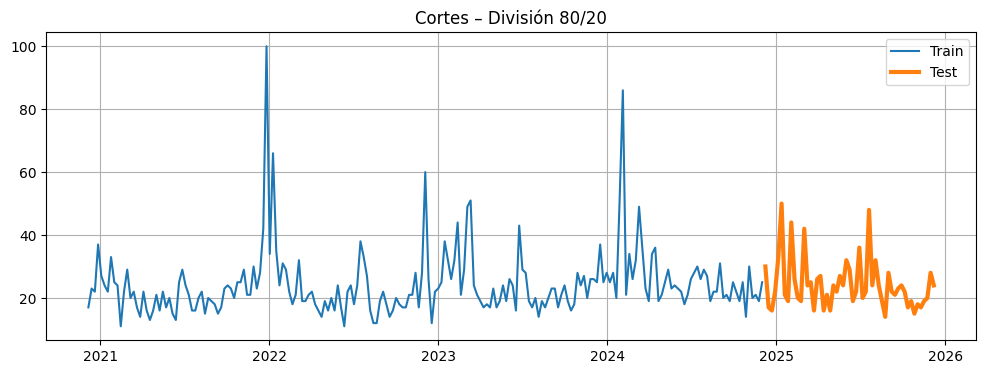

Train: 209
Test : 53


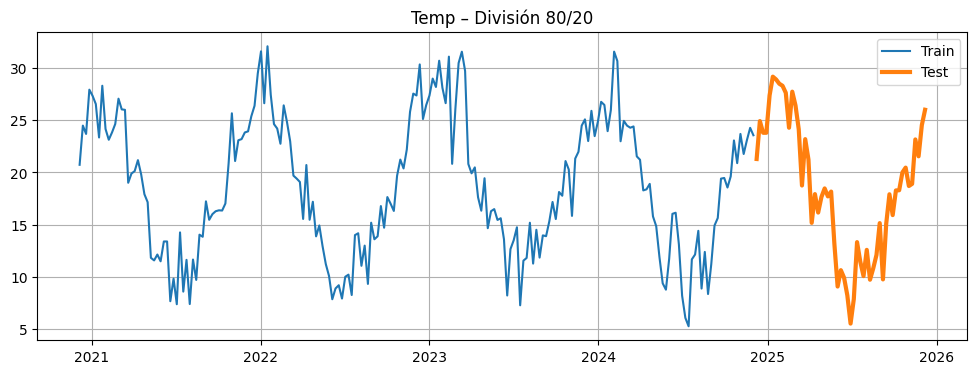

Train: 209
Test : 53


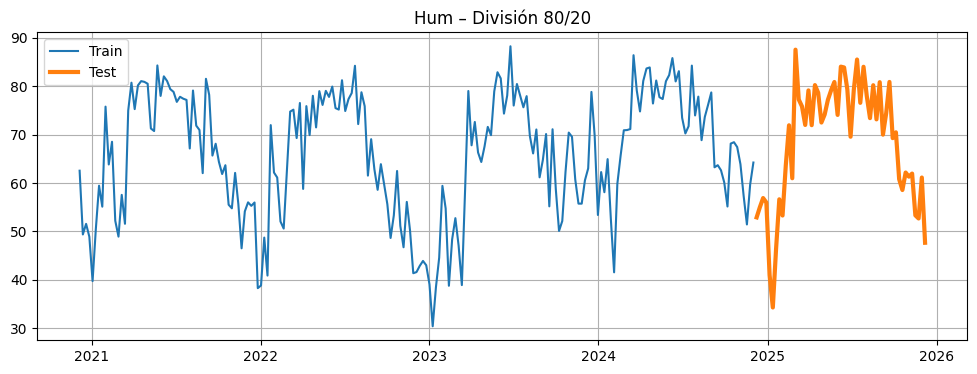

In [6]:
TEST_FRAC = 0.20

for serie in ["Cortes", "Temp", "Hum"]:

    # Formato tipo Prophet (pero solo para dividir)
    df_serie = df[[serie]].reset_index()
    df_serie.columns = ["ds", "y"]

    # Split 80/20
    N = len(df_serie)
    N_TRAIN = int(N * (1 - TEST_FRAC))

    train = df_serie.iloc[:N_TRAIN]
    test  = df_serie.iloc[N_TRAIN:]

    print("Train:", len(train))
    print("Test :", len(test))

    # 📊 Gráfico
    plt.figure(figsize=(12,4))
    plt.plot(train["ds"], train["y"], label="Train")
    plt.plot(test["ds"], test["y"], label="Test", linewidth=3)
    plt.title(f"{serie} – División 80/20")
    plt.legend()
    plt.grid(True)
    plt.show()

## 4. Modelo Prophet



La entrada a Prophet es siempre un dataframe con **ds** e **y**. La columna ds debe tener formato datetime de Pandas.


In [7]:
from prophet import Prophet
import pandas as pd

TEST_FRAC = 0.20

tablas_pred = []

for serie in ["Cortes", "Temp", "Hum"]:

    # Volvemos a preparar la serie
    df_serie = df[[serie]].reset_index()
    df_serie.columns = ["ds", "y"]

    # Split 80/20 (igual que antes)
    N = len(df_serie)
    N_TRAIN = int(N * (1 - TEST_FRAC))

    train = df_serie.iloc[:N_TRAIN]
    test  = df_serie.iloc[N_TRAIN:]

    # 🔵 Modelo
    m = Prophet(
        interval_width=0.95,
        weekly_seasonality=False,
        yearly_seasonality=True
    )

    m.fit(train)

    # 🔵 Predecir SOLO el test
    future = test[["ds"]]
    forecast = m.predict(future)

    # 🔵 Tabla final
    tabla_pred = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    tabla_pred = tabla_pred.merge(test[['ds', 'y']], on='ds', how='left')
    tabla_pred = tabla_pred.rename(columns={'y': 'Real'})
    tabla_pred["Serie"] = serie

    tablas_pred.append(tabla_pred)

tabla_final_prophet = pd.concat(tablas_pred, ignore_index=True)

tabla_final_prophet.head()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat,yhat_lower,yhat_upper,Real,Serie
0,2024-12-08,30.782112,13.216834,47.624540,30.0,Cortes
1,2024-12-15,36.737046,18.377418,55.667937,17.0,Cortes
2,2024-12-22,40.855658,22.607211,58.096419,16.0,Cortes
3,2024-12-29,40.124822,22.349868,57.371984,22.0,Cortes
4,2025-01-05,36.503894,18.858403,53.922626,33.0,Cortes


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


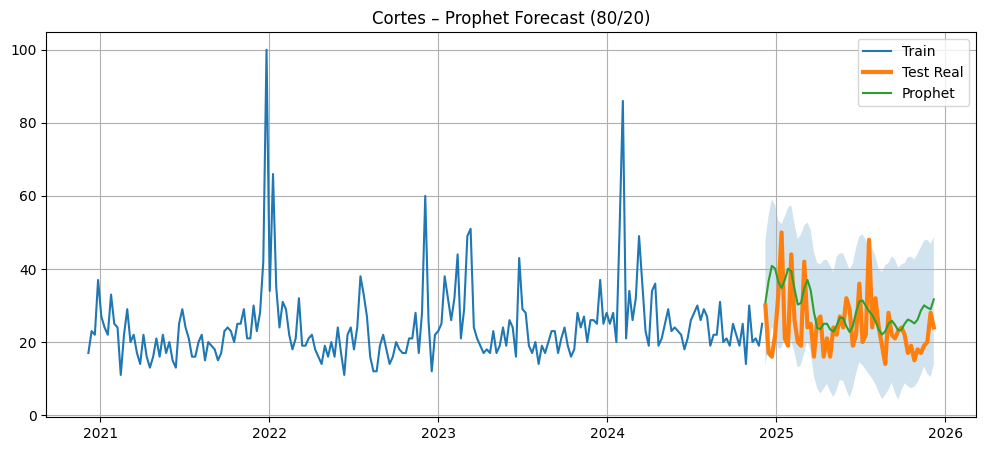

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


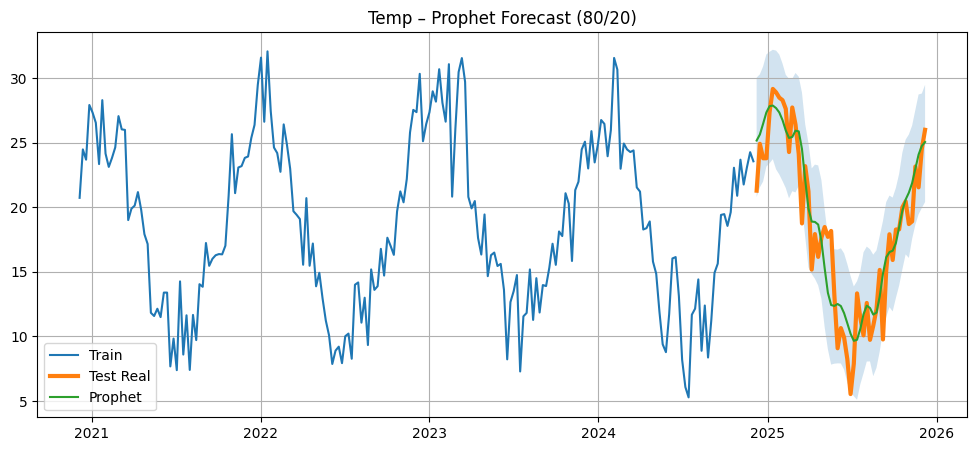

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


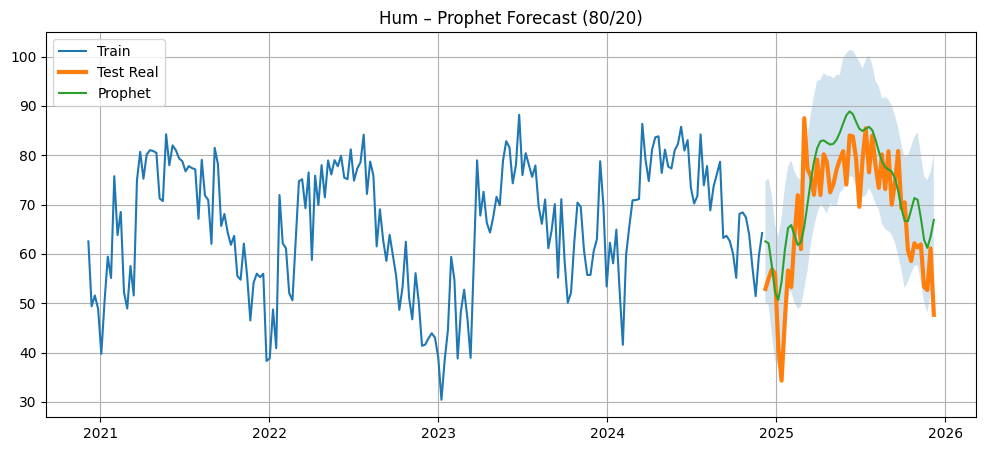

In [8]:
import matplotlib.pyplot as plt

for serie in ["Cortes", "Temp", "Hum"]:

    df_serie = df[[serie]].reset_index()
    df_serie.columns = ["ds", "y"]

    N = len(df_serie)
    N_TRAIN = int(N * 0.80)

    train = df_serie.iloc[:N_TRAIN]
    test  = df_serie.iloc[N_TRAIN:]

    # Modelo
    m = Prophet(
        interval_width=0.95,
        weekly_seasonality=False,
        yearly_seasonality=True
    )

    m.fit(train)

    future = test[["ds"]]
    forecast = m.predict(future)

    # 🔵 GRÁFICO
    plt.figure(figsize=(12,5))

    plt.plot(train["ds"], train["y"], label="Train")
    plt.plot(test["ds"], test["y"], label="Test Real", linewidth=3)
    plt.plot(test["ds"], forecast["yhat"], label="Prophet")

    plt.fill_between(
        forecast["ds"],
        forecast["yhat_lower"],
        forecast["yhat_upper"],
        alpha=0.2
    )

    plt.title(f"{serie} – Prophet Forecast (80/20)")
    plt.legend()
    plt.grid(True)
    plt.show()

## 5. Componentes del modelo

Descomposición en tendencia y estacionalidad anual (semanal deshabilitada). Prophet identifica *changepoints*.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


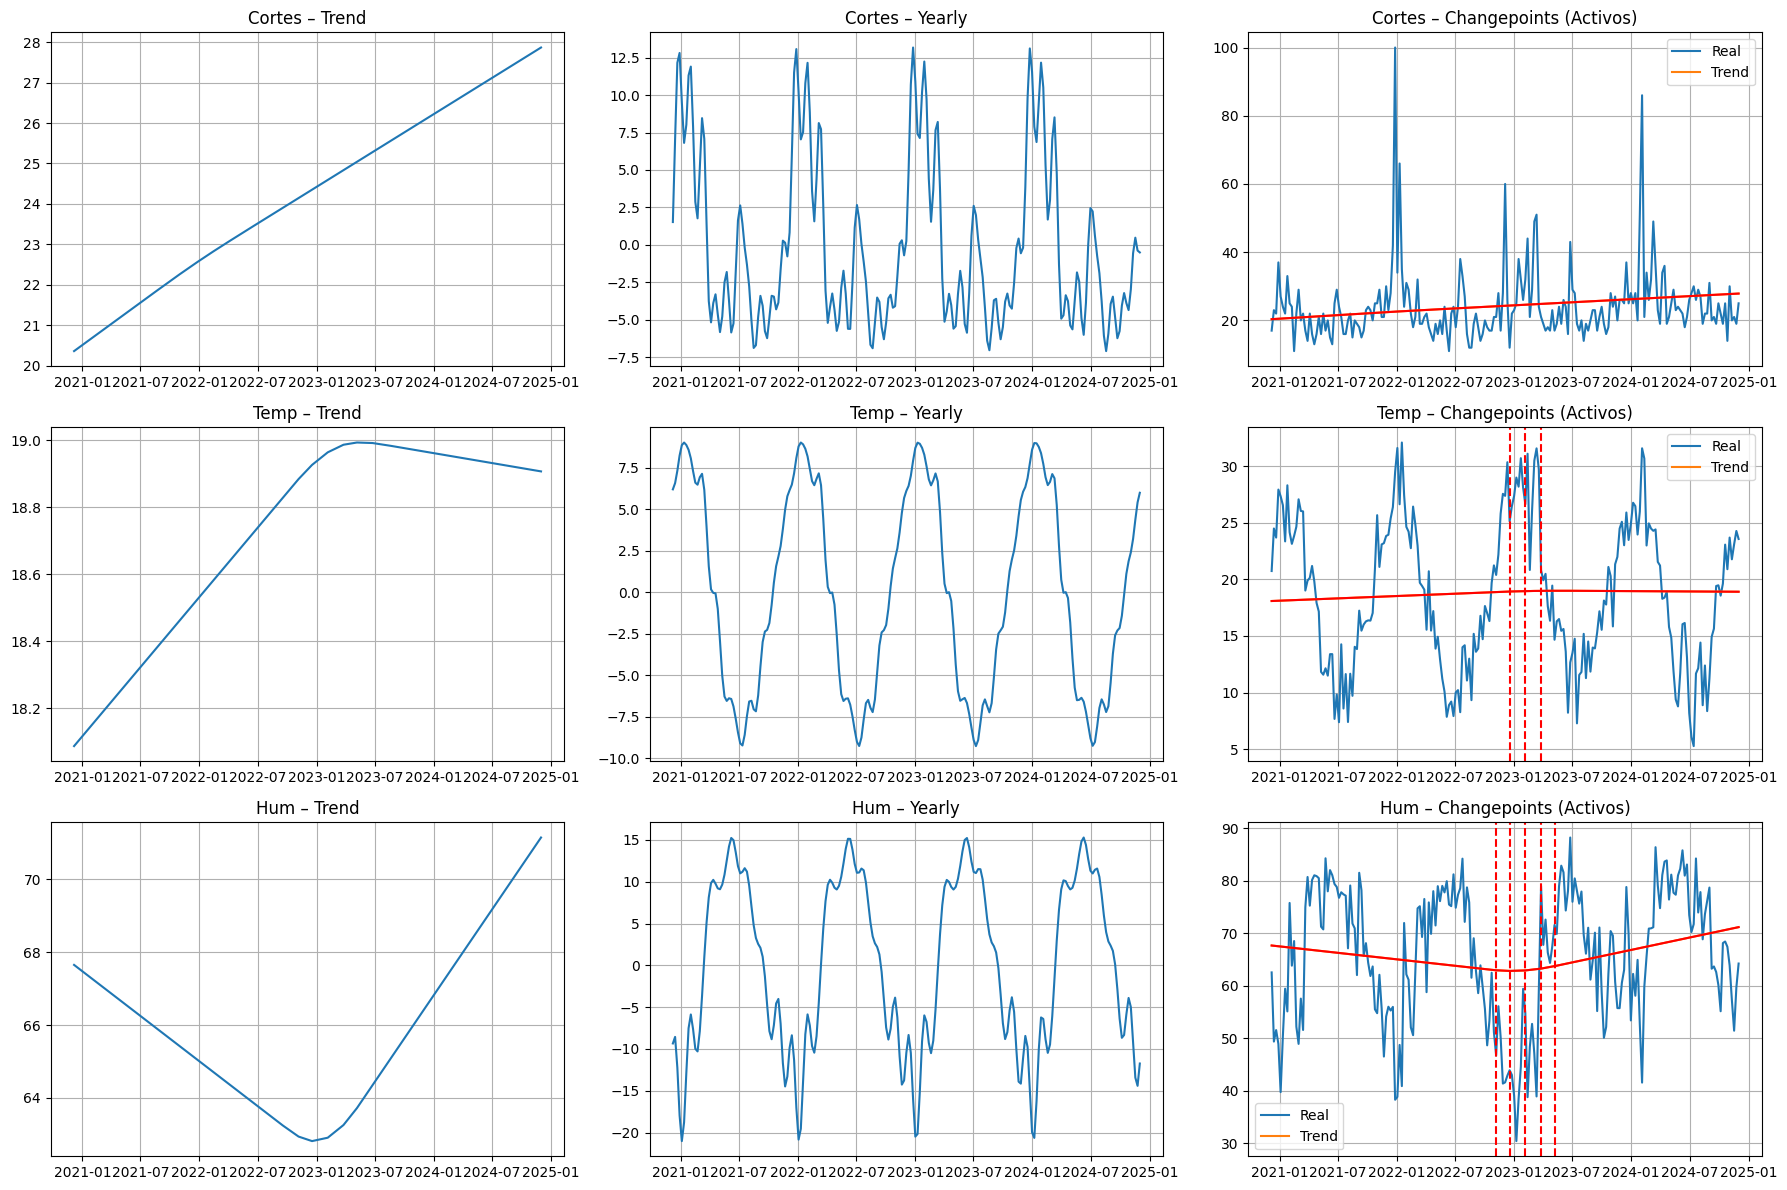

In [9]:
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

TEST_FRAC = 0.20
series_list = ["Cortes", "Temp", "Hum"]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, serie in enumerate(series_list):

    # Preparar datos
    df_serie = df[[serie]].reset_index()
    df_serie.columns = ["ds", "y"]

    N = len(df_serie)
    N_TRAIN = int(N * (1 - TEST_FRAC))
    train = df_serie.iloc[:N_TRAIN]

    # Modelo
    m = Prophet(
        interval_width=0.95,
        weekly_seasonality=False,
        yearly_seasonality=True
    )

    m.fit(train)
    forecast = m.predict(train)

    # 🔵 1) Trend
    axes[i, 0].plot(forecast["ds"], forecast["trend"])
    axes[i, 0].set_title(f"{serie} – Trend")
    axes[i, 0].grid(True)

    # 🔵 2) Yearly
    axes[i, 1].plot(forecast["ds"], forecast["yearly"])
    axes[i, 1].set_title(f"{serie} – Yearly")
    axes[i, 1].grid(True)

    # 🔵 3) Changepoints
    axes[i, 2].plot(train["ds"], train["y"], label="Real")
    axes[i, 2].plot(forecast["ds"], forecast["trend"], label="Trend")

    add_changepoints_to_plot(axes[i, 2], m, forecast)

    axes[i, 2].set_title(f"{serie} – Changepoints (Activos)")
    axes[i, 2].legend()
    axes[i, 2].grid(True)

plt.tight_layout()
plt.show()

## 6. Incertidumbre y changepoints

La mayor incertidumbre proviene de cambios potenciales en la tendencia futura. Prophet identifica changepoints (puntos donde la tendencia cambia). Por defecto agrega 25 changepoints al 80% de los datos. `changepoint_prior_scale` regula la flexibilidad.


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


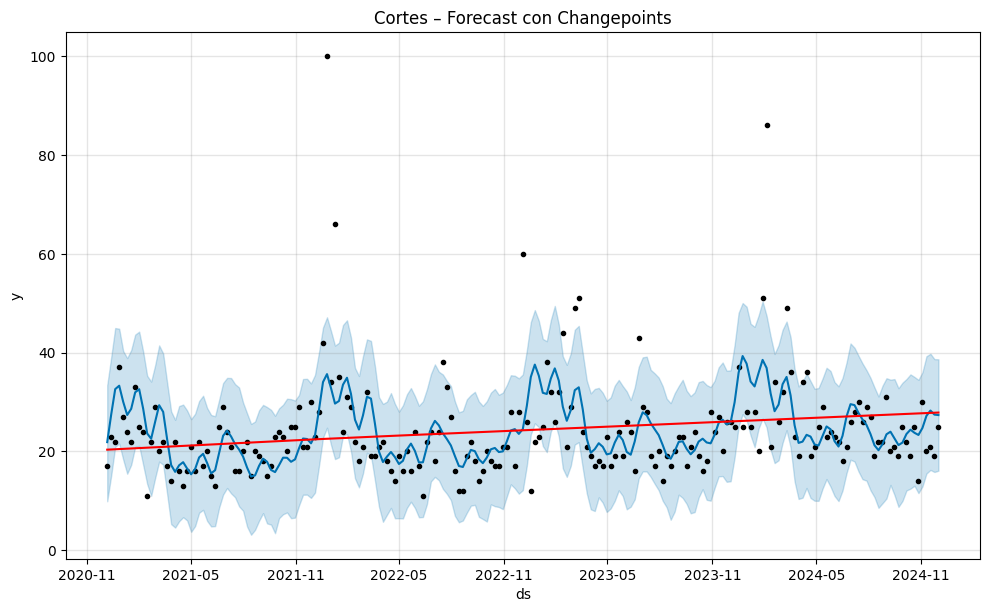

In [10]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

TEST_FRAC = 0.20
serie = "Cortes"

# Preparar datos
df_serie = df[[serie]].reset_index()
df_serie.columns = ["ds", "y"]

N = len(df_serie)
N_TRAIN = int(N * (1 - TEST_FRAC))

train = df_serie.iloc[:N_TRAIN]
test  = df_serie.iloc[N_TRAIN:]

# Modelo
m = Prophet(yearly_seasonality=True)
m.fit(train)

# Predecimos solo sobre train para ver changepoints en ajuste
forecast = m.predict(train)

# 🔵 Plot oficial de Prophet
fig = m.plot(forecast)
add_changepoints_to_plot(fig.gca(), m, forecast)

plt.title(f"{serie} – Forecast con Changepoints")
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


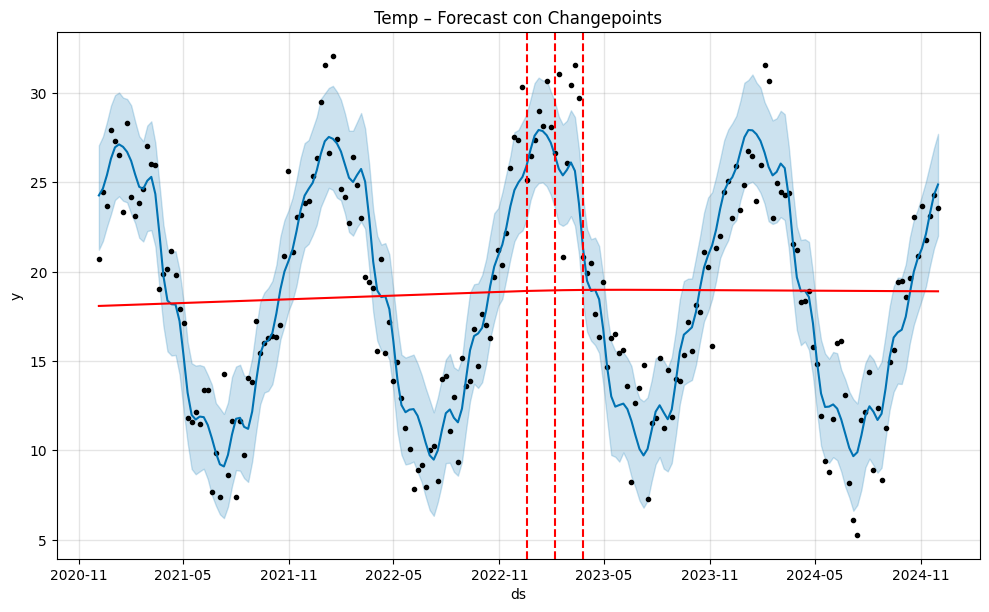

In [11]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

TEST_FRAC = 0.20
serie = "Temp"

# Preparar datos
df_serie = df[[serie]].reset_index()
df_serie.columns = ["ds", "y"]

N = len(df_serie)
N_TRAIN = int(N * (1 - TEST_FRAC))

train = df_serie.iloc[:N_TRAIN]
test  = df_serie.iloc[N_TRAIN:]

# Modelo
m = Prophet(yearly_seasonality=True)
m.fit(train)

# Predecimos solo sobre train para ver changepoints en ajuste
forecast = m.predict(train)

# 🔵 Plot oficial de Prophet
fig = m.plot(forecast)
add_changepoints_to_plot(fig.gca(), m, forecast)

plt.title(f"{serie} – Forecast con Changepoints")
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


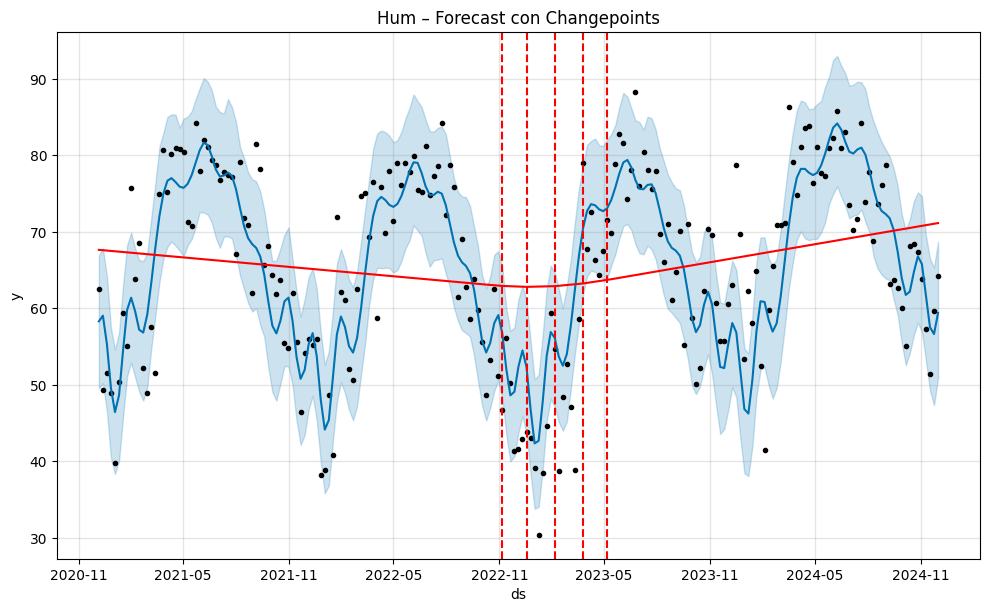

In [12]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

TEST_FRAC = 0.20
serie = "Hum"

# Preparar datos
df_serie = df[[serie]].reset_index()
df_serie.columns = ["ds", "y"]

N = len(df_serie)
N_TRAIN = int(N * (1 - TEST_FRAC))

train = df_serie.iloc[:N_TRAIN]
test  = df_serie.iloc[N_TRAIN:]

# Modelo
m = Prophet(yearly_seasonality=True)
m.fit(train)

# Predecimos solo sobre train para ver changepoints en ajuste
forecast = m.predict(train)

# 🔵 Plot oficial de Prophet
fig = m.plot(forecast)
add_changepoints_to_plot(fig.gca(), m, forecast)

plt.title(f"{serie} – Forecast con Changepoints")
plt.show()

**Métricas de error:**
- **MAE** (Error Absoluto Medio): promedio de los errores en valor absoluto; interpretación directa en las mismas unidades que `y`.
- **MSE** (Error Cuadrático Medio): penaliza más los errores grandes; no está en unidades de `y`.
- **RMSE** (Raíz del MSE): misma escala que `y`, útil para comparar modelos. Valores más bajos indican mejor ajuste.

## 7. Validación y métricas


In [13]:

resultados = []

for serie in ["Cortes", "Temp", "Hum"]:

    # Preparar datos
    df_serie = df[[serie]].reset_index()
    df_serie.columns = ["ds", "y"]

    N = len(df_serie)
    N_TRAIN = int(N * (1 - TEST_FRAC))

    train = df_serie.iloc[:N_TRAIN]
    test  = df_serie.iloc[N_TRAIN:]

    # Modelo
    m = Prophet(yearly_seasonality=True)
    m.fit(train)

    # Crear futuro incluyendo período test
    future = m.make_future_dataframe(periods=len(test), freq='W')
    forecast = m.predict(future)

    # Extraer solo período test
    forecast_test = forecast.iloc[-len(test):].set_index('ds')
    y_real = test.set_index('ds')['y']
    y_pred = forecast_test['yhat']

    # Métricas
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)

    resultados.append([serie, mae, mse, rmse])

    print(f"\n📊 {serie}")
    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



📊 Cortes
MAE:  7.73
MSE:  92.63
RMSE: 9.62

📊 Temp
MAE:  1.90
MSE:  5.77
RMSE: 2.40

📊 Hum
MAE:  7.07
MSE:  75.15
RMSE: 8.67


## 8. Optimización de hiperparámetros

Se intentó primero realizar la optimización con **Optuna** (optimización bayesiana), pero generaba muchas complicaciones debido a la incompatibilidad entre las librerías usadas por Prophet y Optuna (por ejemplo, CmdStan y sus dependencias, errores de *Operation not permitted*, *Optimization terminated abnormally*, etc.). Por ello se optó por continuar con **Grid Search**, que resulta más estable y compatible con el ecosistema de Prophet.

El Grid Search evalúa **72 combinaciones** de hiperparámetros (`changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `n_changepoints`) para cada serie (Cortes, Temp, Hum), seleccionando la configuración con menor RMSE en el conjunto de validación (20% final).

In [14]:
def objective(trial):
    """Función objetivo para Optuna: entrena Prophet con parámetros sugeridos y devuelve RMSE."""
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True),
        'changepoint_range': trial.suggest_float('changepoint_range', 0.6, 0.95),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.1, 20.0, log=True),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        'n_changepoints': trial.suggest_int('n_changepoints', 10, 50),
    }
    m_trial = Prophet(
        interval_width=0.95,
        weekly_seasonality=False,
        yearly_seasonality=True,
        **params
    )
    m_trial.fit(train, seed=SEED)
    future_trial = m_trial.make_future_dataframe(periods=len(test), freq='W')
    forecast_trial = m_trial.predict(future_trial)
    y_pred_trial = forecast_trial.iloc[-len(test):]['yhat'].values
    y_real_trial = test['y'].values
    rmse = np.sqrt(mean_squared_error(y_real_trial, y_pred_trial))
    return rmse

# Ejecutar optimización (30 trials; aumentar n_trials para mayor precisión)
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True, n_jobs=1)

# Mejores parámetros encontrados y métricas
best_params = study.best_params
print('Mejores hiperparámetros encontrados:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Calcular MAE, MSE y RMSE del mejor modelo
m_opt = Prophet(interval_width=0.95, weekly_seasonality=False, yearly_seasonality=True, **best_params)
m_opt.fit(train, seed=SEED)
forecast_opt = m_opt.predict(m_opt.make_future_dataframe(periods=len(test), freq='W'))
y_pred_opt = forecast_opt.iloc[-len(test):]['yhat'].values
y_real_opt = test['y'].values
mae_opt = mean_absolute_error(y_real_opt, y_pred_opt)
mse_opt = mean_squared_error(y_real_opt, y_pred_opt)
rmse_opt = np.sqrt(mse_opt)
print('\nMétricas del modelo optimizado:')
print(f'  MAE:  {mae_opt:.2f}')
print(f'  MSE:  {mse_opt:.2f}')
print(f'  RMSE: {rmse_opt:.2f}')


  0%|          | 0/30 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seaso

Mejores hiperparámetros encontrados:
  changepoint_prior_scale: 0.021203973399088187
  changepoint_range: 0.8891673084670304
  seasonality_prior_scale: 1.2586880376920753
  seasonality_mode: multiplicative
  n_changepoints: 26

Métricas del modelo optimizado:
  MAE:  5.34
  MSE:  52.91
  RMSE: 7.27


In [15]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

TEST_FRAC = 0.20

best_params = {
    "changepoint_prior_scale": 0.335620422128,
    "changepoint_range": 0.7767888775369695,
    "seasonality_prior_scale": 0.6905746814982644,
    "seasonality_mode": "multiplicative",
    "n_changepoints": 38
}

resultados_opt = []

for serie in ["Cortes", "Temp", "Hum"]:

    # Preparar datos
    df_serie = df[[serie]].reset_index()
    df_serie.columns = ["ds", "y"]

    N = len(df_serie)
    N_TRAIN = int(N * (1 - TEST_FRAC))

    train = df_serie.iloc[:N_TRAIN]
    test  = df_serie.iloc[N_TRAIN:]

    # 🔵 Modelo optimizado
    m = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=best_params["changepoint_prior_scale"],
        changepoint_range=best_params["changepoint_range"],
        seasonality_prior_scale=best_params["seasonality_prior_scale"],
        seasonality_mode=best_params["seasonality_mode"],
        n_changepoints=best_params["n_changepoints"]
    )

    m.fit(train)

    future = m.make_future_dataframe(periods=len(test), freq='W')
    forecast = m.predict(future)

    forecast_test = forecast.iloc[-len(test):].set_index("ds")
    y_real = test.set_index("ds")["y"]
    y_pred = forecast_test["yhat"]

    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)

    resultados_opt.append([serie, mae, mse, rmse])

    print(f"\n🚀 {serie} – Modelo Optimizado")
    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")

resultados_opt_df = pd.DataFrame(
    resultados_opt,
    columns=["Serie", "MAE_opt", "MSE_opt", "RMSE_opt"]
)

print("\nResumen optimizado:")
print(resultados_opt_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



🚀 Cortes – Modelo Optimizado
MAE:  8.10
MSE:  107.23
RMSE: 10.36

🚀 Temp – Modelo Optimizado
MAE:  2.21
MSE:  7.76
RMSE: 2.79


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



🚀 Hum – Modelo Optimizado
MAE:  6.56
MSE:  70.48
RMSE: 8.40

Resumen optimizado:
    Serie   MAE_opt     MSE_opt   RMSE_opt
0  Cortes  8.099971  107.230619  10.355222
1    Temp  2.210388    7.762890   2.786196
2     Hum  6.557659   70.481229   8.395310


**Grid Search** — Se define el espacio de búsqueda y se evalúan todas las combinaciones para cada serie. Los mejores parámetros se almacenan en `prophet_results` y son los utilizados en las predicciones finales.

In [16]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED      = 42
TEST_FRAC = 0.20

# ── Grid de hiperparámetros ──────────────────────────────────
PARAM_GRID_PROPHET = {
    'changepoint_prior_scale' : [0.01, 0.05, 0.1, 0.3],
    'seasonality_prior_scale' : [0.1, 1.0, 10.0],
    'seasonality_mode'        : ['additive', 'multiplicative'],
    'n_changepoints'          : [15, 25, 40],
}

# Todas las combinaciones
all_combos = list(itertools.product(
    PARAM_GRID_PROPHET['changepoint_prior_scale'],
    PARAM_GRID_PROPHET['seasonality_prior_scale'],
    PARAM_GRID_PROPHET['seasonality_mode'],
    PARAM_GRID_PROPHET['n_changepoints'],
))
print(f"Total combinaciones a evaluar: {len(all_combos)}")


Total combinaciones a evaluar: 72


In [17]:
# ── Helpers ──────────────────────────────────────────────────
def prep_prophet_df(df, serie):
    """Convierte df al formato ds/y que requiere Prophet."""
    out = df[[serie]].reset_index()
    out.columns = ['ds', 'y']
    return out

def fit_predict_prophet(params, train, test):
    """Entrena Prophet con params y predice el período test."""
    m = Prophet(
        interval_width        = 0.95,
        weekly_seasonality    = False,
        yearly_seasonality    = True,
        changepoint_prior_scale  = params['changepoint_prior_scale'],
        seasonality_prior_scale  = params['seasonality_prior_scale'],
        seasonality_mode         = params['seasonality_mode'],
        n_changepoints           = params['n_changepoints'],
    )
    import logging
    logging.getLogger('prophet').setLevel(logging.ERROR)
    logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

    m.fit(train)
    forecast = m.predict(test[['ds']])
    return forecast['yhat'].values

In [18]:
prophet_results  = {}   # {serie: {'best_params', 'y_pred', 'y_true', métricas}}

for serie in ['Cortes', 'Temp', 'Hum']:
    print(f"\n{'='*55}")
    print(f"  Prophet Grid Search → {serie}")
    print(f"{'='*55}")

    df_serie = prep_prophet_df(df, serie)
    N        = len(df_serie)
    N_TRAIN  = int(N * (1 - TEST_FRAC))

    train = df_serie.iloc[:N_TRAIN]
    test  = df_serie.iloc[N_TRAIN:]

    best_rmse   = np.inf
    best_params = None
    best_pred   = None
    results_gs  = []

    for i, (cps, sps, mode, ncp) in enumerate(all_combos):
        params = {
            'changepoint_prior_scale': cps,
            'seasonality_prior_scale': sps,
            'seasonality_mode'       : mode,
            'n_changepoints'         : ncp,
        }
        try:
            y_pred = fit_predict_prophet(params, train, test)
            rmse   = np.sqrt(mean_squared_error(test['y'].values, y_pred))
            results_gs.append({**params, 'rmse': rmse})

            if rmse < best_rmse:
                best_rmse   = rmse
                best_params = params
                best_pred   = y_pred

            # Progreso cada 20 combinaciones
            if (i + 1) % 20 == 0 or (i + 1) == len(all_combos):
                print(f"  [{i+1}/{len(all_combos)}] mejor RMSE hasta ahora: {best_rmse:.4f}")

        except Exception as e:
            print(f"  ⚠ Error en combo {i}: {e}")
            continue

    # Métricas del mejor modelo
    y_true = test['y'].values
    mae    = mean_absolute_error(y_true, best_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, best_pred))

    prophet_results[serie] = {
        'best_params': best_params,
        'y_pred'     : best_pred,
        'y_true'     : y_true,
        'rmse'       : round(rmse, 4),
        'mae'        : round(mae, 4),
        'grid_df'    : pd.DataFrame(results_gs).sort_values('rmse'),
    }

    print(f"\n  ✓ Mejores parámetros:")
    for k, v in best_params.items():
        print(f"    {k}: {v}")
    print(f"  RMSE={rmse:.4f}  MAE={mae:.4f}")


  Prophet Grid Search → Cortes
  [20/72] mejor RMSE hasta ahora: 8.5504
  [40/72] mejor RMSE hasta ahora: 8.5504
  [60/72] mejor RMSE hasta ahora: 8.5504
  [72/72] mejor RMSE hasta ahora: 8.5504

  ✓ Mejores parámetros:
    changepoint_prior_scale: 0.01
    seasonality_prior_scale: 0.1
    seasonality_mode: multiplicative
    n_changepoints: 15
  RMSE=8.5504  MAE=6.7762

  Prophet Grid Search → Temp
  [20/72] mejor RMSE hasta ahora: 2.4045
  [40/72] mejor RMSE hasta ahora: 2.3483
  [60/72] mejor RMSE hasta ahora: 2.3483
  [72/72] mejor RMSE hasta ahora: 2.3483

  ✓ Mejores parámetros:
    changepoint_prior_scale: 0.1
    seasonality_prior_scale: 10.0
    seasonality_mode: multiplicative
    n_changepoints: 25
  RMSE=2.3483  MAE=1.9052

  Prophet Grid Search → Hum
  [20/72] mejor RMSE hasta ahora: 7.3545
  [40/72] mejor RMSE hasta ahora: 7.3545
  [60/72] mejor RMSE hasta ahora: 7.3545
  [72/72] mejor RMSE hasta ahora: 7.3545

  ✓ Mejores parámetros:
    changepoint_prior_scale: 0.01
  

In [19]:
# ── Tabla resumen ────────────────────────────────────────────
print(f"\n{'='*55}")
print("  Resumen Prophet – mejores modelos")
print(f"{'='*55}")
rows = []
for serie, res in prophet_results.items():
    rows.append({'Serie': serie, 'RMSE': res['rmse'], 'MAE': res['mae'],
                 **res['best_params']})
df_resumen = pd.DataFrame(rows)
display(df_resumen)


  Resumen Prophet – mejores modelos


,Serie,RMSE,MAE,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,n_changepoints
0,Cortes,8.5504,6.7762,0.01,0.1,multiplicative,15
1,Temp,2.3483,1.9052,0.10,10.0,multiplicative,25
2,Hum,7.3545,5.3409,0.01,0.1,additive,15


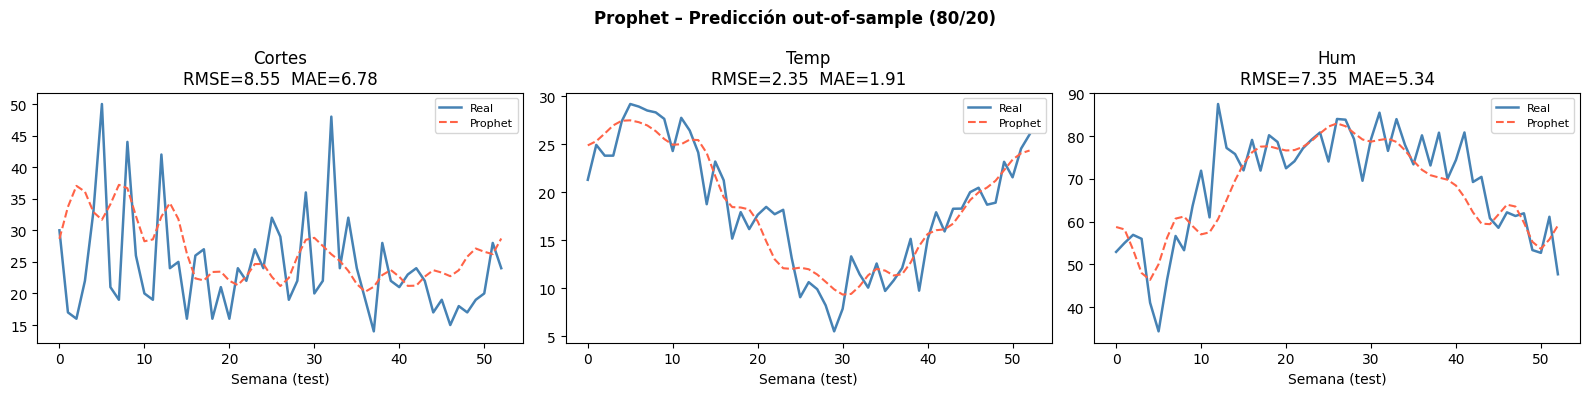


✓ Sección Prophet completa


In [20]:
# ── Gráficos ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Prophet – Predicción out-of-sample (80/20)', fontweight='bold')

for ax, serie in zip(axes, ['Cortes', 'Temp', 'Hum']):
    res    = prophet_results[serie]
    y_true = res['y_true']
    y_pred = res['y_pred']
    x      = np.arange(len(y_true))

    ax.plot(x, y_true, label='Real',    color='steelblue', lw=1.8)
    ax.plot(x, y_pred, label='Prophet', color='tomato',    lw=1.5, linestyle='--')
    ax.set_title(f'{serie}\nRMSE={res["rmse"]:.2f}  MAE={res["mae"]:.2f}')
    ax.set_xlabel('Semana (test)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('prophet_predicciones.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✓ Sección Prophet completa")

## 9. Prophet multivariado

En contraste con los modelos univariados anteriores, aquí se utiliza **Prophet con regresores adicionales**: la variable objetivo es **Cortes** y las covariables **Temp** y **Hum** se incorporan mediante `add_regressor()`. El modelo aprovecha la información de temperatura y humedad para mejorar la predicción de cortes de energía. Se mantiene la misma división 80/20, métricas (MAE, MSE, RMSE) y optimización por Grid Search.

In [21]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

TEST_FRAC = 0.20
SEED = 42

# ── DataFrame multivariado: Cortes (y) + Temp, Hum (regresores) ─────────────
df_multivar = df.reset_index()
df_multivar.columns = ['ds', 'y', 'Temp', 'Hum']
df_multivar = df_multivar[['ds', 'y', 'Temp', 'Hum']]  # y = Cortes

N = len(df_multivar)
N_TRAIN = int(N * (1 - TEST_FRAC))
train_mv = df_multivar.iloc[:N_TRAIN]
test_mv = df_multivar.iloc[N_TRAIN:]

# ── Grid de hiperparámetros (mismo espacio que univariado) ──────────────────
PARAM_GRID = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.3],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'n_changepoints': [15, 25, 40],
}
all_combos = list(itertools.product(
    PARAM_GRID['changepoint_prior_scale'],
    PARAM_GRID['seasonality_prior_scale'],
    PARAM_GRID['seasonality_mode'],
    PARAM_GRID['n_changepoints'],
))
print(f"Prophet multivariado – Cortes ~ Temp + Hum")
print(f"Total combinaciones: {len(all_combos)}")

Prophet multivariado – Cortes ~ Temp + Hum
Total combinaciones: 72


In [22]:
def fit_predict_prophet_multivar(params, train, test):
    """Entrena Prophet multivariado (Cortes ~ Temp + Hum) y predice test."""
    m = Prophet(
        interval_width=0.95,
        weekly_seasonality=False,
        yearly_seasonality=True,
        changepoint_prior_scale=params['changepoint_prior_scale'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        seasonality_mode=params['seasonality_mode'],
        n_changepoints=params['n_changepoints'],
    )
    m.add_regressor('Temp', mode='additive')
    m.add_regressor('Hum', mode='additive')
    m.fit(train)
    # predict requiere ds + columnas de regresores en el futuro
    future = test[['ds', 'Temp', 'Hum']].copy()
    forecast = m.predict(future)
    return forecast['yhat'].values

# ── Grid Search ───────────────────────────────────────────────────────────
best_rmse = np.inf
best_params_mv = None
best_pred_mv = None
results_gs_mv = []

for i, (cps, sps, mode, ncp) in enumerate(all_combos):
    params = {
        'changepoint_prior_scale': cps,
        'seasonality_prior_scale': sps,
        'seasonality_mode': mode,
        'n_changepoints': ncp,
    }
    try:
        y_pred = fit_predict_prophet_multivar(params, train_mv, test_mv)
        rmse = np.sqrt(mean_squared_error(test_mv['y'].values, y_pred))
        results_gs_mv.append({**params, 'rmse': rmse})
        if rmse < best_rmse:
            best_rmse = rmse
            best_params_mv = params
            best_pred_mv = y_pred
        if (i + 1) % 20 == 0 or (i + 1) == len(all_combos):
            print(f"  [{i+1}/{len(all_combos)}] mejor RMSE: {best_rmse:.4f}")
    except Exception as e:
        print(f"  ⚠ Error combo {i}: {e}")
        continue

y_true_mv = test_mv['y'].values
mae_mv = mean_absolute_error(y_true_mv, best_pred_mv)
mse_mv = mean_squared_error(y_true_mv, best_pred_mv)
rmse_mv = np.sqrt(mse_mv)

print(f"\n✓ Mejores parámetros multivariado:")
for k, v in best_params_mv.items():
    print(f"  {k}: {v}")
print(f"\nMétricas (Cortes ~ Temp + Hum):")
print(f"  MAE:  {mae_mv:.4f}")
print(f"  MSE:  {mse_mv:.4f}")
print(f"  RMSE: {rmse_mv:.4f}")

  [20/72] mejor RMSE: 8.9977
  [40/72] mejor RMSE: 8.9977
  [60/72] mejor RMSE: 8.8922
  [72/72] mejor RMSE: 8.8918

✓ Mejores parámetros multivariado:
  changepoint_prior_scale: 0.3
  seasonality_prior_scale: 1.0
  seasonality_mode: additive
  n_changepoints: 40

Métricas (Cortes ~ Temp + Hum):
  MAE:  6.9194
  MSE:  79.0640
  RMSE: 8.8918


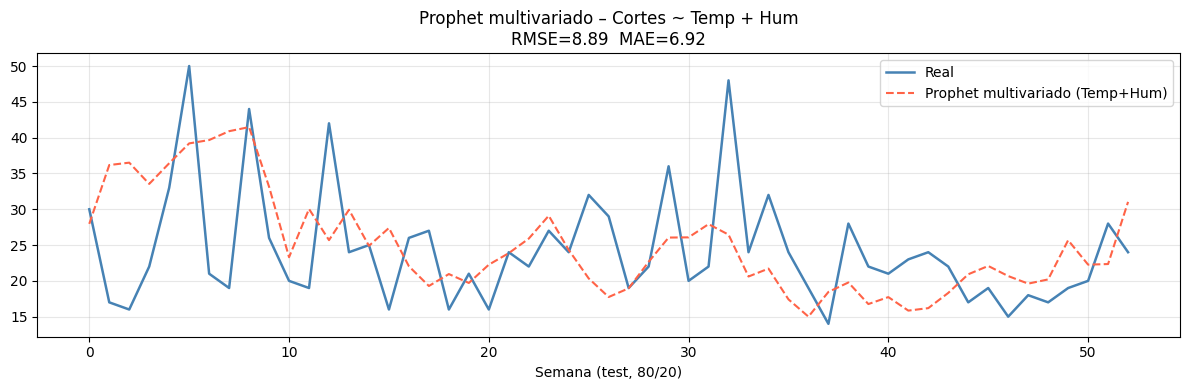


Comparación Cortes (test 20%):
  Univariado:   RMSE=8.5504
  Multivariado: RMSE=8.8918 (Temp + Hum como regresores)


In [23]:
# ── Gráfico: Prophet multivariado – Cortes (real vs predicción) ────────────
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
x = np.arange(len(y_true_mv))
ax.plot(x, y_true_mv, label='Real', color='steelblue', lw=1.8)
ax.plot(x, best_pred_mv, label='Prophet multivariado (Temp+Hum)', color='tomato', lw=1.5, linestyle='--')
ax.set_title(f'Prophet multivariado – Cortes ~ Temp + Hum\nRMSE={rmse_mv:.2f}  MAE={mae_mv:.2f}')
ax.set_xlabel('Semana (test, 80/20)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prophet_multivariado_cortes.png', dpi=120, bbox_inches='tight')
plt.show()

# Comparación rápida: univariado vs multivariado para Cortes
rmse_uni = prophet_results['Cortes']['rmse']
print(f"\nComparación Cortes (test 20%):")
print(f"  Univariado:   RMSE={rmse_uni:.4f}")
print(f"  Multivariado: RMSE={rmse_mv:.4f} (Temp + Hum como regresores)")

# Resultados multivariado (para uso posterior en guardado)
prophet_multivar_results = {
    'best_params': best_params_mv,
    'y_pred': best_pred_mv,
    'y_true': y_true_mv,
    'rmse': round(rmse_mv, 4),
    'mae': round(mae_mv, 4),
}

## 10. Guardado final

In [24]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/SDT/Resultados"


Mounted at /content/drive


**Guardado final:** Se exportan las predicciones del conjunto de test (20% final) para cada serie: modelos **univariados** (Cortes, Temp, Hum) y el modelo **multivariado** (Cortes ~ Temp + Hum). Incluye valores reales (`y_true`), predicciones (`y_pred`) y métricas (RMSE, MAE). Los resultados corresponden a los modelos optimizados por Grid Search.

In [25]:
# Reconstruir fechas del test
df_serie_export = df[['Cortes']].reset_index()
df_serie_export.columns = ['ds', 'y']
N_TRAIN_EXPORT  = int(len(df_serie_export) * 0.80)
fechas_test     = df_serie_export.iloc[N_TRAIN_EXPORT:]['ds'].values

all_preds   = []
all_metrics = []

# ── Modelos univariados (Cortes, Temp, Hum) ───────────────────────────────
for serie, res in prophet_results.items():
    df_pred = pd.DataFrame({
        'model' : 'Prophet',
        'serie' : serie,
        'date'  : fechas_test[:len(res['y_true'])],
        'y_true': res['y_true'],
        'y_pred': res['y_pred'],
    })
    all_preds.append(df_pred)
    all_metrics.append({
        'model': 'Prophet',
        'serie': serie,
        'rmse' : res['rmse'],
        'mae'  : res['mae'],
    })

# ── Modelo multivariado (Cortes ~ Temp + Hum) ──────────────────────────────
res_mv = prophet_multivar_results
df_pred_mv = pd.DataFrame({
    'model' : 'Prophet_multivariado',
    'serie' : 'Cortes',
    'date'  : fechas_test[:len(res_mv['y_true'])],
    'y_true': res_mv['y_true'],
    'y_pred': res_mv['y_pred'],
})
all_preds.append(df_pred_mv)
all_metrics.append({
    'model': 'Prophet_multivariado',
    'serie': 'Cortes',
    'rmse' : res_mv['rmse'],
    'mae'  : res_mv['mae'],
})

df_predictions = pd.concat(all_preds)
df_metrics     = pd.DataFrame(all_metrics)

df_predictions.to_csv(f"{BASE_PATH}/predictions_Prophet.csv", index=False)
df_metrics.to_csv(f"{BASE_PATH}/metrics_Prophet.csv", index=False)

print("✔ Prophet (univariado + multivariado) guardado correctamente")
print(df_metrics)

✔ Prophet (univariado + multivariado) guardado correctamente
                  model   serie    rmse     mae
0               Prophet  Cortes  8.5504  6.7762
1               Prophet    Temp  2.3483  1.9052
2               Prophet     Hum  7.3545  5.3409
3  Prophet_multivariado  Cortes  8.8918  6.9194
